### Assign bacterial hosts using CRISPR spacers

In [1]:
### load packages
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import duckdb
import seaborn as sns

pl.Config.set_streaming_chunk_size(10_000)  # number of rows per chunk

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


polars.config.Config

In [ ]:
%%bash
### Run nf-crisprhost on UHGV
# nextflow run . \
#     -c /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/assets/configs/conf/uw_hyak.config \
#     --spacer_fasta https://portal.nersc.gov/dna/microbial/prokpubs/spacer_database_resources/nr_spacers_hq-taxoselected_25-05-10.fna.gz \
#     --virus_fasta https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/votus_hq_plus.fna.gz \
#     --hyak_queue 'ckpt' \
#     --hyak_partition 'pedslabs' \
#     --output nr_spacers_hq-taxoselected_25-05-10_v_uhgv_hq_plus_votu_reps.tsv

In [ ]:
%%bash
### Run nf-crisprhost on UHVDB
# nextflow run . \
#     -c /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/assets/configs/conf/uw_hyak.config \
#     --spacer_fasta https://portal.nersc.gov/dna/microbial/prokpubs/spacer_database_resources/nr_spacers_hq-taxoselected_25-05-10.fna.gz \
#     --virus_fasta /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_10/uhvdb_votu_reps.fna \
#     --hyak_queue 'ckpt' \
#     --hyak_partition 'pedslabs' \
#     --output nr_spacers_hq-taxoselected_25-05-10_v_uhvdb_r2025_10_votu_reps.tsv

In [ ]:
%%bash
### download global crispr db duckdb
# aria2c https://spacers.jgi.doe.gov/s3-gateway/global_crispr_db_spacertaxa_2025-05-02.duckdb

In [ ]:
### Create files for spacer analysis
# # Connect to locally downloaded copy of the database:
# DB_PATH = "global_crispr_db_spacertaxa_2025-05-02.duckdb"
# con = duckdb.connect(DB_PATH)

# # Check database size
# db_stats = Path(DB_PATH).stat()
# print(f"Database Size: {db_stats.st_size / (1024 * 1024):.2f} MB")

# # Test a simple query
# query = "SELECT COUNT(*) as count FROM sample_tbl"
# result = pl.from_pandas(con.execute(query).df())
# print(f"\nTotal samples: {result['count'][0]:,}")

In [ ]:
### create a parquet of hq spacers (+ their cluster) from human-associated ecosystems
# ctype_eco_query = """
# COPY (
#     SELECT tmp.spacer_id, tmp.crispr_repeat, tmp.ecosystem_base, r.lca_full, r.lca_genus, r.lca_family, r.lca_class, h.cluster_id
#     FROM (
#             SELECT s.spacer_id, s.crispr_repeat, s.library, l.library, l.ecosystem_base
#             FROM spacer_hq_tbl s, sample_tbl l
#             WHERE s.library=l.library AND l.ecosystem_base LIKE '%Human%'
#         ) as tmp, repeat_tbl as r, spacer_hq_clusters as h
#     WHERE tmp.crispr_repeat=r.repeat_cluster
#     AND tmp.spacer_id=h.spacer_id
# ) TO 'hq_human_spacer_metadata.parquet'
# (FORMAT PARQUET);
# """
# con.execute(ctype_eco_query)

### Benchmark using UHGV HQ genomes

In [ ]:
### Load spacerextractor hits to UHGV and filter
# # load hits file
# hits_file = '/gscratch/stf/carsonjm/nf-crisprhost_test/nf-crisprhost/nr_spacers_hq-taxoselected_25-05-10_v_uhgv_hq_plus_votu_reps.tsv'

# hits_df = (
#     pl.scan_csv(hits_file, separator='\t', new_columns=["spacer_cluster_id", "target_id", "start", "end", "strand", "n_mismatches"])
#         .select(['spacer_cluster_id', 'target_id', 'n_mismatches'])
#         .filter(pl.col('n_mismatches') < 2)
#         .unique(subset=['spacer_cluster_id', 'target_id'])
#         .collect(engine='streaming')
# )

# hits_df.write_parquet('nr_spacers_hq_250510_v_uhgv_hq_plus_votu_reps.parquet')

In [ ]:
### Identify unique spacer cluster in UHGV hits
# unique_uhgv_spacer_clusters = (
#     pl.scan_parquet('nr_spacers_hq_250510_v_uhgv_hq_plus_votu_reps.parquet')
#         .select('spacer_cluster_id')
#         .unique()
#         .collect(engine='streaming')
# )

# uhgv_spacer_cluster_set = set(unique_uhgv_spacer_clusters['spacer_cluster_id'])
# print(f"Number of unique spacer clusters with UHGV hits: {len(uhgv_spacer_cluster_set):,}")

In [ ]:
### create UHGV hit to species/genus/family parquet files
# human_spacer_metadata = pl.scan_parquet('hq_human_spacer_metadata.parquet')

# ### create cluster to species parquet
# species_df = (
#     human_spacer_metadata
#         .select(['cluster_id', 'lca_full'])
#         .filter(
#             (~pl.col('lca_full').str.ends_with(';s__unclassified')) &
#             (pl.col('lca_full') != 'NA')
#         )
#         .with_columns([
#             pl.col('cluster_id').cast(pl.Categorical),
#             pl.col('lca_full').cast(pl.Categorical),
#         ])
#         .group_by(['cluster_id', 'lca_full'])
#         .agg([pl.len().alias('connections')])
#         .group_by('cluster_id')
#         .agg([
#             pl.col('connections').sum().alias('total_connections'),
#             pl.col('connections').max().alias('max_connections'),
#             pl.col("lca_full").sort_by("connections", descending=True).first().alias('top_species')
#         ])
#         .with_columns([
#             (pl.col('max_connections') / pl.col('total_connections')).alias('species_agreement'),
#         ])
#         .filter(
#             (pl.col('species_agreement') >= 0.7) &
#             (pl.col('cluster_id').is_in(uhgv_spacer_cluster_set))
#         )
#         .select(['cluster_id', 'top_species'])
#         .collect(engine='streaming')
# )

# species_df.write_parquet('hq_human_spacer_to_uhgv_species.parquet')

# ### create cluster to genus parquet
# genus_df = (
#     human_spacer_metadata
#         .select(['cluster_id', 'lca_genus'])
#         .filter(
#             (~pl.col('lca_genus').str.ends_with(';g__unclassified')) &
#             (pl.col('lca_genus') != 'NA')
#         )
#         .with_columns([
#             pl.col('cluster_id').cast(pl.Categorical),
#             pl.col('lca_genus').cast(pl.Categorical),
#         ])
#         .group_by(['cluster_id', 'lca_genus'])
#         .agg([pl.len().alias('connections')])
#         .group_by('cluster_id')
#         .agg([
#             pl.col('connections').sum().alias('total_connections'),
#             pl.col('connections').max().alias('max_connections'),
#             pl.col("lca_genus").sort_by("connections", descending=True).first().alias('top_genus')
#         ])
#         .with_columns([
#             (pl.col('max_connections') / pl.col('total_connections')).alias('genus_agreement'),
#         ])
#         .filter(
#             (pl.col('genus_agreement') >= 0.7) &
#             (pl.col('cluster_id').is_in(uhgv_spacer_cluster_set))
#         )
#         .select(['cluster_id', 'top_genus'])
#         .collect(engine='streaming')
# )

# genus_df.write_parquet('hq_human_spacer_to_uhgv_genus.parquet')

### create cluster to family parquet
# family_df = (
#     human_spacer_metadata
#         .select(['cluster_id', 'lca_family'])
#         .filter(
#             (~pl.col('lca_family').str.ends_with(';f__unclassified')) &
#             (pl.col('lca_family') != 'NA')
#         )
#         .with_columns([
#             pl.col('cluster_id').cast(pl.Categorical),
#             pl.col('lca_family').cast(pl.Categorical),
#         ])
#         .group_by(['cluster_id', 'lca_family'])
#         .agg([pl.len().alias('connections')])
#         .group_by('cluster_id')
#         .agg([
#             pl.col('connections').sum().alias('total_connections'),
#             pl.col('connections').max().alias('max_connections'),
#             pl.col("lca_family").sort_by("connections", descending=True).first().alias('top_family')
#         ])
#         .with_columns([
#             (pl.col('max_connections') / pl.col('total_connections')).alias('family_agreement'),
#         ])
#         .filter(
#             (pl.col('family_agreement') >= 0.7) &
#             (pl.col('cluster_id').is_in(uhgv_spacer_cluster_set))
#         )
#         .select(['cluster_id', 'top_family'])
#         .collect(engine='streaming')
# )

# family_df.write_parquet('hq_human_spacer_to_uhgv_family.parquet')

In [ ]:
# ### Create dictionary of cluster_id to taxonomic assignment
# uhgv_species_dict = {k: v[0] for k, v in pl.read_parquet('hq_human_spacer_to_uhgv_species.parquet').rows_by_key(key=["cluster_id"], unique=True).items()}
# uhgv_genus_dict = {k: v[0] for k, v in pl.read_parquet('hq_human_spacer_to_uhgv_genus.parquet').rows_by_key(key=["cluster_id"], unique=True).items()}
# uhgv_family_dict = {k: v[0] for k, v in pl.read_parquet('hq_human_spacer_to_uhgv_family.parquet').rows_by_key(key=["cluster_id"], unique=True).items()}

In [ ]:
# ### create UHGV hit to taxa dataframe
# uhgv_hit2taxa = (
#     pl.scan_parquet('nr_spacers_hq_250510_v_uhgv_hq_plus_votu_reps.parquet')
#         .with_columns([
#             pl.col('spacer_cluster_id').replace_strict(uhgv_species_dict, default=None).alias('predicted_species'),
#             pl.col('spacer_cluster_id').replace_strict(uhgv_genus_dict, default=None).alias('predicted_genus'),
#             pl.col('spacer_cluster_id').replace_strict(uhgv_family_dict, default=None).alias('predicted_family'),
#         ])
#         .with_columns([
#             pl.col('target_id').cast(pl.String).str.split('_species=').list[0].alias('target_id'),
#             pl.col('predicted_species').cast(pl.String).str.split(';s__').list[1].alias('species'),
#             pl.col('predicted_genus').cast(pl.String).str.split(';g__').list[1].str.split(';').list[0].alias('genus'),
#             pl.col('predicted_family').cast(pl.String).str.split(';f__').list[1].str.split(';').list[0].alias('family'),
#         ])
#         .collect(engine='streaming')
# )

In [ ]:
# ### Load UHGV metadata
# hq_votus = (
#     pl.read_csv('votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'crispr_total_connections', 'crispr_host_agreement', 'crispr_host_lineage_gtdb_r207'])
#         .filter(
#             (pl.col('checkv_completeness') >= 90) &
#             (pl.col('viral_confidence') == 'Confident')
#         )
#         .with_columns(pl.col('crispr_total_connections').cast(pl.Float64))
#         .with_columns(pl.col('crispr_host_agreement').cast(pl.Float64))
#         .with_columns([
#             pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_species'),
#             pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_genus'),
#             pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_family'),
#             pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_order'),
#             pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_class'),
#             pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_phylum')
#         ])
# )
# print("Total UHGV HQ vOTUs:", hq_votus['uhgv_genome'].n_unique())
# print("Number of UHGV HQ vOTUs with predicted hosts from kmer method:", hq_votus.filter(pl.col('crispr_total_connections') > 0)['uhgv_genome'].n_unique())
# print("Number with species-level assignments:", hq_votus.filter(pl.col('host_species').is_not_null())['uhgv_genome'].n_unique())
# print("Number with genus-level assignments:", hq_votus.filter(pl.col('host_genus').is_not_null())['uhgv_genome'].n_unique())
# print("Number with family-level assignments:", hq_votus.filter(pl.col('host_family').is_not_null())['uhgv_genome'].n_unique())
# print("Number with order-level assignments:", hq_votus.filter(pl.col('host_order').is_not_null())['uhgv_genome'].n_unique())
# print("Number with class-level assignments:", hq_votus.filter(pl.col('host_class').is_not_null())['uhgv_genome'].n_unique())
# print("Number with phylum-level assignments:", hq_votus.filter(pl.col('host_phylum').is_not_null())['uhgv_genome'].n_unique())

In [ ]:
# ### Calculate agreement between new CRISPR assignments and UHGV with different consensus thresholds
# recalls = []
# precisions = []
# f1s = []
# num_hits = []
# props = []
# ranks = []
# fps = []
# agreements = []

# for rank in ['species', 'genus', 'family']:#, 'phylum']:#, 'order', 'class', 'phylum']:
#     for agreement in [0.1, 0.25, 0.5, 0.6, 0.7, 0.8, 0.9]:
#         uhgv_new = (
#             uhgv_hit2taxa
#                 .lazy()
#                 # .with_columns(pl.col('phylum').str.replace('Pseudomonadota', 'Proteobacteria'))
#                 # .with_columns(pl.col('phylum').str.replace('Bacillota', 'Firmicutes'))
#                 # .with_columns(pl.col('phylum').str.replace('Actinomycetota', 'Actinobacteriota'))
#                 # .with_columns(pl.col('phylum').str.split('_').list[0])
#                 # # .with_columns(pl.col('class').str.replace('Actinomycetes', 'Actinomycetia'))
#                 # # .with_columns(pl.col('class').str.split('_').list[0])
#                 .filter(pl.col(rank).is_not_null())
#                 .group_by(['target_id', rank])
#                 .agg([
#                     pl.len().alias(f'{rank}_count')
#                 ])
#                 .sort(f'{rank}_count', descending=True)
#                 .group_by('target_id')
#                 .agg([
#                     pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
#                     pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
#                     pl.col(rank).first().alias(f'consensus_{rank}')
#                 ])
#                 .with_columns([
#                     (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
#                 ])
#                 .filter(pl.col(f'{rank}_agreement') >= agreement)
#                 .collect(engine='streaming')
#         )

#         # identify UHVDB agreement with UHGV phist assignments
#         uhgv_uhvdb_join = (
#             uhgv_new
#                 .with_columns(pl.col(f'consensus_{rank}'))
#                 .join(hq_votus, left_on='target_id', right_on='uhgv_genome', how='left')
#         )
#         for num_hit in [1]:
#             tp = uhgv_uhvdb_join.filter(pl.col(f'consensus_{rank}') == pl.col(f'host_{rank}')).filter(pl.col(f'{rank}_total') >= num_hit).height
#             fp = uhgv_uhvdb_join.filter((pl.col(f'consensus_{rank}') != pl.col(f'host_{rank}')) & (~pl.col(f'consensus_{rank}').is_null())).filter(pl.col(f'{rank}_total') >= num_hit).height
#             fn = uhgv_uhvdb_join.filter(pl.col(f'consensus_{rank}').is_null()).height
#             recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#             precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#             f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

#             recalls.append(recall)
#             precisions.append(precision)
#             f1s.append(f1)
#             num_hits.append(num_hit)
#             props.append(uhgv_new.filter(pl.col(f'{rank}_total') >= num_hit).height / hq_votus['uhgv_genome'].n_unique())
#             ranks.append(rank)
#             agreements.append(agreement)

In [ ]:
# ### Plot agreement between new CRISPR assignments and UHGV with different consensus thresholds
# precision_df = pl.DataFrame({
#     'rank': ranks,
#     'num_hits': num_hits,
#     'recall': recalls,
#     'precision': precisions,
#     'f1_score': f1s,
#     'proportion_assigned': props,
#     'agreement_threshold': agreements,
# })

# # plot results as a seaborn boxplot
# sns.lineplot(data=precision_df, x='agreement_threshold', y='precision', hue='rank')
# plt.title('New CRISPR agreement with UHGV')
# plt.xlabel('CRISPRS spacer consensus threshold')
# plt.ylabel('Proportion agreement with UHGV')
# plt.legend(title='Taxonomic Rank')
# # horizontal line at y=0.9
# plt.axhline(y=0.9, color='r', linestyle='--')
# plt.axvline(x=0.7, color='grey', linestyle='--')
# plt.ylim(0,1)
# plt.show()

In [ ]:
# ### Calculate agreement between new CRISPR assignments and UHGV with different spacer hit count thresholds
# recalls = []
# precisions = []
# f1s = []
# num_hits = []
# props = []
# ranks = []
# fps = []

# for rank in ['species', 'genus', 'family']:#, 'phylum']:#, 'order', 'class', 'phylum']:
#     uhgv_new = (
#         uhgv_hit2taxa
#             .lazy()
#             # .with_columns(pl.col('phylum').str.replace('Pseudomonadota', 'Proteobacteria'))
#             # .with_columns(pl.col('phylum').str.replace('Bacillota', 'Firmicutes'))
#             # .with_columns(pl.col('phylum').str.replace('Actinomycetota', 'Actinobacteriota'))
#             # .with_columns(pl.col('phylum').str.split('_').list[0])
#             # # .with_columns(pl.col('class').str.replace('Actinomycetes', 'Actinomycetia'))
#             # # .with_columns(pl.col('class').str.split('_').list[0])
#             .filter(pl.col(rank).is_not_null())
#             .group_by(['target_id', rank])
#             .agg([
#                 pl.len().alias(f'{rank}_count')
#             ])
#             .sort(f'{rank}_count', descending=True)
#             .group_by('target_id')
#             .agg([
#                 pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
#                 pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
#                 pl.col(rank).first().alias(f'consensus_{rank}')
#             ])
#             .with_columns([
#                 (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
#             ])
#             .filter(pl.col(f'{rank}_agreement') >= 0.7)
#             .collect(engine='streaming')
#     )

#     # identify UHVDB agreement with UHGV phist assignments
#     uhgv_uhvdb_join = (
#         uhgv_new
#             .with_columns(pl.col(f'consensus_{rank}'))
#             .join(hq_votus, left_on='target_id', right_on='uhgv_genome', how='left')
#     )
#     for num_hit in [1, 3, 5, 10, 20, 50]:
#         tp = uhgv_uhvdb_join.filter(pl.col(f'consensus_{rank}') == pl.col(f'host_{rank}')).filter(pl.col(f'{rank}_total') >= num_hit).height
#         fp = uhgv_uhvdb_join.filter((pl.col(f'consensus_{rank}') != pl.col(f'host_{rank}')) & (~pl.col(f'consensus_{rank}').is_null())).filter(pl.col(f'{rank}_total') >= num_hit).height
#         fn = uhgv_uhvdb_join.filter(pl.col(f'consensus_{rank}').is_null()).height
#         recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#         f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

#         recalls.append(recall)
#         precisions.append(precision)
#         f1s.append(f1)
#         num_hits.append(num_hit)
#         props.append(uhgv_new.filter(pl.col(f'{rank}_total') >= num_hit).height / hq_votus['uhgv_genome'].n_unique())
#         ranks.append(rank)

In [ ]:
# ### Plot agreement between new CRISPR assignments and UHGV with different spacer hit count thresholds
# precision_df = pl.DataFrame({
#     'rank': ranks,
#     'num_hits': num_hits,
#     'recall': recalls,
#     'precision': precisions,
#     'f1_score': f1s,
#     'proportion_assigned': props
# })

# # plot results as a seaborn boxplot
# sns.lineplot(data=precision_df, x='num_hits', y='precision', hue='rank')
# plt.title('New CRISPR host agreement with UHGV')
# plt.xlabel('Number CRISPR connections')
# plt.ylabel('Proportion agreement with UHGV')
# plt.legend(title='Taxonomic Rank')
# # horizontal line at y=0.9
# plt.axhline(y=0.9, color='r', linestyle='--')
# # plt.axvline(x=20, color='grey', linestyle='--')
# plt.ylim(0,1)
# plt.show()

In [ ]:
# # plot results as a seaborn boxplot
# sns.lineplot(data=precision_df, x='num_hits', y='proportion_assigned', hue='rank')
# plt.title('CRISPR host agreement with UHGV')
# plt.xlabel('Number CRISPR connections')
# plt.ylabel('Agreement with UHGV')
# plt.legend(title='Taxonomic Rank')
# # horizontal line at y=0.9
# plt.axhline(y=0.9, color='r', linestyle='--')
# # plt.axvline(x=20, color='grey', linestyle='--')
# plt.ylim(0,1)
# plt.show()

In [ ]:
# ### Calculate proportion of UHGV assigned with different spacer hit count thresholds for new and old methods
# props = []
# methods = []
# num_hits = []
# ranks = []

# for rank in ['species', 'genus', 'family']:
#     for num_hit in [1, 3, 5, 10, 20, 50]:
#         uhgv_new = (
#             uhgv_hit2taxa
#                 .lazy()
#                 .filter(
#                     (pl.col(rank).is_not_null()) &
#                     (pl.col('target_id').str.starts_with('UHGV'))
#                 )
#                 .group_by(['target_id', rank])
#                 .agg([
#                     pl.len().alias(f'{rank}_count')
#                 ])
#                 .sort(f'{rank}_count', descending=True)
#                 .group_by('target_id')
#                 .agg([
#                     pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
#                     pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
#                     pl.col(rank).first().alias(f'consensus_{rank}')
#                 ])
#                 .with_columns([
#                     (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
#                 ])
#                 .filter(pl.col(f'{rank}_agreement') >= 0.7)
#                 .filter(pl.col(f'{rank}_total') >= num_hit)
#                 .collect(engine='streaming')
                
#         )
#         props.append(uhgv_new.height / hq_votus['uhgv_genome'].n_unique())
#         methods.append('UHVDB')
#         num_hits.append(num_hit)
#         ranks.append(rank)

#         uhgv_old = (
#             hq_votus
#                 .filter(pl.col(f'host_{rank}').is_not_null())
#                 .filter(pl.col('crispr_total_connections') >= num_hit)
#                 .unique('uhgv_genome')
#         )

#         props.append(uhgv_old.height / hq_votus['uhgv_genome'].n_unique())
#         methods.append('UHGV')
#         num_hits.append(num_hit)
#         ranks.append(rank)

In [ ]:
# ### Plot annotaiton rate comparison between new and old methods
# annotation_rate_df = pl.DataFrame({
#     'Taxonomic Rank': ranks,
#     'num_hits': num_hits,
#     'props': props,
#     'Method': methods
# })

# # plot results as a seaborn boxplot
# sns.lineplot(data=annotation_rate_df, x='num_hits', y='props', hue='Taxonomic Rank', style='Method')
# plt.title('New CRISPR vs UHGV CRISPR annotation rate')
# plt.xlabel('Number of CRISPR connections')
# plt.ylabel('Proportion of UHGV HQ genomes with annotation')
# # horizontal line at y=0.9
# plt.axhline(y=0.9, color='r', linestyle='--')
# plt.ylim(0,1)
# plt.show()

### Assign hosts to UHVDB genomes

In [ ]:
%%bash
### count number of total hits
# grep -c "^" /gscratch/stf/carsonjm/nf-crisprhost_test/nf-crisprhost/nr_spacers_hq-taxoselected_25-05-10_v_uhvdb_r2025_10_votu_reps.tsv
# 1,477,458,773 total hits

In [ ]:
# ### Load spacerextractor hits to UHVDB and filter
# import polars as pl

# # load hits file and write out filter parquet
# hits_file = '/gscratch/stf/carsonjm/nf-crisprhost_test/nf-crisprhost/nr_spacers_hq-taxoselected_25-05-10_v_uhvdb_r2025_10_votu_reps.tsv'

# (
#     pl.scan_csv(hits_file, separator='\t', new_columns=["spacer_cluster_id", "target_id", "start", "end", "strand", "n_mismatches"])
#         .select(['spacer_cluster_id', 'target_id', 'n_mismatches'])
#         .filter(pl.col('n_mismatches') < 2)
#         .unique(subset=['spacer_cluster_id', 'target_id'])
#         .sink_parquet('nr_spacers_hq_250510_v_uhvdb_r2025_10_filtered_hits.parquet')
# )

In [ ]:
# ### Identify unique spacer cluster in UHVDB hits
# unique_uhvdb_spacer_clusters = (
#     pl.scan_parquet('nr_spacers_hq_250510_v_uhvdb_r2025_10_filtered_hits.parquet')
#         .select('spacer_cluster_id')
#         .unique()
#         .collect(engine='streaming')
# )

# uhvdb_spacer_cluster_set = set(unique_uhvdb_spacer_clusters['spacer_cluster_id'])
# print(f"Number of unique spacer clusters with UHDB hits: {len(uhvdb_spacer_cluster_set):,}")

Number of unique spacer clusters with UHDB hits: 28,812,386


In [ ]:
# ### load filtered hits and create hit to species/genus/family parquet files
# human_spacer_metadata = pl.scan_parquet('hq_human_spacer_metadata.parquet')

# ### create cluster to species parquet
# species_df = (
#     human_spacer_metadata
#         .select(['cluster_id', 'lca_full'])
#         .filter(
#             (~pl.col('lca_full').str.ends_with(';s__unclassified')) &
#             (pl.col('lca_full') != 'NA')
#         )
#         .with_columns([
#             pl.col('cluster_id').cast(pl.Categorical),
#             pl.col('lca_full').cast(pl.Categorical),
#         ])
#         .group_by(['cluster_id', 'lca_full'])
#         .agg([pl.len().alias('connections')])
#         .group_by('cluster_id')
#         .agg([
#             pl.col('connections').sum().alias('total_connections'),
#             pl.col('connections').max().alias('max_connections'),
#             pl.col("lca_full").sort_by("connections", descending=True).first().alias('top_species')
#         ])
#         .with_columns([
#             (pl.col('max_connections') / pl.col('total_connections')).alias('species_agreement'),
#         ])
#         .filter(
#             (pl.col('species_agreement') >= 0.7) &
#             (pl.col('cluster_id').is_in(uhvdb_spacer_cluster_set))
#         )
#         .select(['cluster_id', 'top_species'])
#         .collect(engine='streaming')
# )

# species_df.write_parquet('uhvdb_hq_human_spacer_species.parquet')

# ### create cluster to genus parquet
# genus_df = (
#     human_spacer_metadata
#         .select(['cluster_id', 'lca_genus'])
#         .filter(
#             (~pl.col('lca_genus').str.ends_with(';g__unclassified')) &
#             (pl.col('lca_genus') != 'NA')
#         )
#         .with_columns([
#             pl.col('cluster_id').cast(pl.Categorical),
#             pl.col('lca_genus').cast(pl.Categorical),
#         ])
#         .group_by(['cluster_id', 'lca_genus'])
#         .agg([pl.len().alias('connections')])
#         .group_by('cluster_id')
#         .agg([
#             pl.col('connections').sum().alias('total_connections'),
#             pl.col('connections').max().alias('max_connections'),
#             pl.col("lca_genus").sort_by("connections", descending=True).first().alias('top_genus')
#         ])
#         .with_columns([
#             (pl.col('max_connections') / pl.col('total_connections')).alias('genus_agreement'),
#         ])
#         .filter(
#             (pl.col('genus_agreement') >= 0.7) &
#             (pl.col('cluster_id').is_in(uhvdb_spacer_cluster_set))
#         )
#         .select(['cluster_id', 'top_genus'])
#         .collect(engine='streaming')
# )

# genus_df.write_parquet('uhvdb_hq_human_spacer_genus.parquet')

# ### create cluster to family parquet
# family_df = (
#     human_spacer_metadata
#         .select(['cluster_id', 'lca_family'])
#         .filter(
#             (~pl.col('lca_family').str.ends_with(';f__unclassified')) &
#             (pl.col('lca_family') != 'NA')
#         )
#         .with_columns([
#             pl.col('cluster_id').cast(pl.Categorical),
#             pl.col('lca_family').cast(pl.Categorical),
#         ])
#         .group_by(['cluster_id', 'lca_family'])
#         .agg([pl.len().alias('connections')])
#         .group_by('cluster_id')
#         .agg([
#             pl.col('connections').sum().alias('total_connections'),
#             pl.col('connections').max().alias('max_connections'),
#             pl.col("lca_family").sort_by("connections", descending=True).first().alias('top_family')
#         ])
#         .with_columns([
#             (pl.col('max_connections') / pl.col('total_connections')).alias('family_agreement'),
#         ])
#         .filter(
#             (pl.col('family_agreement') >= 0.7) &
#             (pl.col('cluster_id').is_in(uhvdb_spacer_cluster_set))
#         )
#         .select(['cluster_id', 'top_family'])
#         .collect(engine='streaming')
# )

# family_df.write_parquet('uhvdb_hq_human_spacer_family.parquet')

In [2]:
### load host predictions
species_dict = {k: v[0] for k, v in pl.read_parquet('uhvdb_hq_human_spacer_species.parquet').rows_by_key(key=["cluster_id"], unique=True).items()}
genus_dict = {k: v[0] for k, v in pl.read_parquet('uhvdb_hq_human_spacer_genus.parquet').rows_by_key(key=["cluster_id"], unique=True).items()}
family_dict = {k: v[0] for k, v in pl.read_parquet('uhvdb_hq_human_spacer_family.parquet').rows_by_key(key=["cluster_id"], unique=True).items()}

In [3]:
uhvdb_hit2taxa = (
    pl.scan_parquet('nr_spacers_hq_250510_v_uhvdb_r2025_10_filtered_hits.parquet')
        .with_columns([
            pl.col('spacer_cluster_id').replace_strict(species_dict, default=None).alias('predicted_species'),
            pl.col('spacer_cluster_id').replace_strict(genus_dict, default=None).alias('predicted_genus'),
            pl.col('spacer_cluster_id').replace_strict(family_dict, default=None).alias('predicted_family'),
        ])
        .with_columns([
            pl.col('target_id').cast(pl.String).str.split('_tr=').list[0].alias('target_id'),
            pl.col('predicted_species').cast(pl.String).str.split(';s__').list[1].alias('species'),
            pl.col('predicted_genus').cast(pl.String).str.split(';g__').list[1].str.split(';').list[0].alias('genus'),
            pl.col('predicted_family').cast(pl.String).str.split(';f__').list[1].str.split(';').list[0].alias('family')
        ])
        .collect(engine='streaming')
)

In [ ]:
# ### Calculate proportion of UHVDB assigned with different spacer hit count thresholds
# uhvdb_info = (
#     pl.read_csv(
#         '../figure_2/vclust/uhvdb_vclust_cluster_info_final.tsv',
#         separator='\t', columns=['contig_id', 'completeness_method', 'votu_rep']
#     )
# )

# # identify species reps
# species_reps = set(
#     uhvdb_info['votu_rep']
# )

# props = []
# methods = []
# num_hits = []
# ranks = []

# for rank in ['species', 'genus', 'family']:
#     for num_hit in [1, 3, 5, 10, 20, 50]:
#         uhvdb = (
#             uhvdb_hit2taxa
#                 .lazy()
#                 .filter(
#                     (pl.col(rank).is_not_null())
#                     # (pl.col('target_id').is_in(species_reps))
#                 )
#                 .group_by(['target_id', rank])
#                 .agg([
#                     pl.len().alias(f'{rank}_count')
#                 ])
#                 .sort(f'{rank}_count', descending=True)
#                 .group_by('target_id')
#                 .agg([
#                     pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
#                     pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
#                     pl.col(rank).first().alias(f'consensus_{rank}')
#                 ])
#                 .with_columns([
#                     (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
#                 ])
#                 .filter(pl.col(f'{rank}_agreement') >= 0.7)
#                 .filter(pl.col(f'{rank}_total') >= num_hit)
#                 .collect(engine='streaming')
#         )
#         props.append(uhvdb.height / uhvdb_info['votu_rep'].n_unique())
#         methods.append('UHVDB')
#         num_hits.append(num_hit)
#         ranks.append(rank)

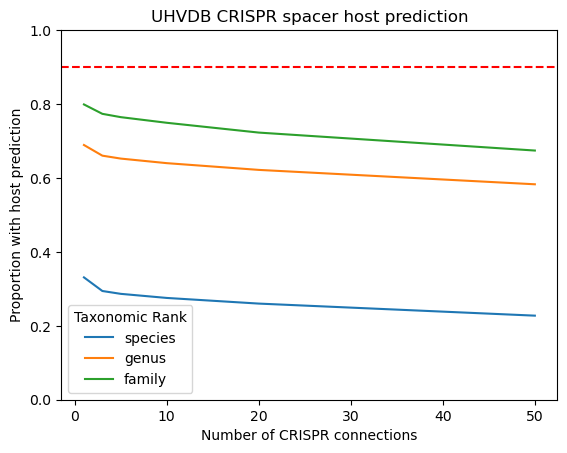

In [ ]:
# ### Plot annotaiton rate for UHVDB
# annotation_rate_df = pl.DataFrame({
#     'Taxonomic Rank': ranks,
#     'num_hits': num_hits,
#     'props': props,
#     'Method': methods
# })

# # plot results as a seaborn boxplot
# sns.lineplot(data=annotation_rate_df, x='num_hits', y='props', hue='Taxonomic Rank')
# plt.title('UHVDB CRISPR spacer host prediction')
# plt.xlabel('Number of CRISPR connections')
# plt.ylabel('Proportion with host prediction')
# # horizontal line at y=0.9
# plt.axhline(y=0.9, color='r', linestyle='--')
# plt.ylim(0,1)
# plt.show()

In [5]:
### Create final df for UHVDB CRISPR host prediction
uhvdb_info = (
    pl.read_csv(
        '../uhvdb_final_files/r2025_10/uhvdb_clustering_thru_votus.tsv',
        separator='\t', columns=['seq_name', 'votu_rep']
    )
)

# identify species reps
species_reps = set(
    uhvdb_info['votu_rep']
)

uhvdb_crisprtaxa = uhvdb_info.unique('votu_rep')[['votu_rep']]
for rank in ['species', 'genus', 'family']:
    uhvdb_crisprtaxa = uhvdb_crisprtaxa.join(
        uhvdb_hit2taxa
            .lazy()
            .filter(
                (pl.col(rank).is_not_null())
                # (pl.col('target_id').is_in(species_reps))
            )
            .group_by(['target_id', rank])
            .agg([
                pl.len().alias(f'{rank}_count')
            ])
            .sort(f'{rank}_count', descending=True)
            .group_by('target_id')
            .agg([
                pl.col(f'{rank}_count').sum().alias(f'{rank}_total'),
                pl.col(f'{rank}_count').max().alias(f'{rank}_max_count'),
                pl.col(rank).first().alias(f'consensus_{rank}')
            ])
            .with_columns([
                (pl.col(f'{rank}_max_count') / pl.col(f'{rank}_total')).alias(f'{rank}_agreement'),
            ])
            .filter(pl.col(f'{rank}_agreement') >= 0.7)
            .collect(engine='streaming'),
        left_on='votu_rep', right_on='target_id', how='left'
    )

In [6]:
uhvdb_crisprtaxa.write_csv('uhvdb_r2025_10_species_spacer_host_predictions.tsv', separator='\t')